# Lesson 14 — Inference for proportions (one & two)

*Part 2 · Lesson 14 of 20  ·  data: US Births 2014*

**←** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb) **→**

**Same idea, another way:**  [Another dataset →](14-inference-proportions~another-dataset.ipynb)  ·  [The code behind it →](14-inference-proportions~the-code.ipynb)

So far our inference has been about **means** — average house sizes, average tooth lengths. But a huge
share of real questions are about **proportions**: the *fraction* of something. What share of babies
are born underweight? Is that share **different** for mothers who smoke?

In this lesson we estimate a proportion from a sample, wrap it in a **confidence interval**, and run a
**z-test** against a benchmark — first for **one** group, then for the **difference between two**. As
always we'll *earn* the textbook formulas by **simulating** the sampling distribution and watching it
turn into a bell curve, then confirm the libraries agree. Our data: **1,000 US births from 2014**.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
sl.use_course_style()

BIRTHS_URL = 'https://www.openintro.org/data/csv/births14.csv'
births = sl.load_csv('births14.csv', url=BIRTHS_URL)

print(f'{len(births):,} births, {births.shape[1]} columns')
# The two columns we'll lean on, and their exact label strings:
print('lowbirthweight labels:', list(births['lowbirthweight'].dropna().unique()))
print('habit labels:         ', list(births['habit'].dropna().unique()))
births[['weight', 'weeks', 'habit', 'lowbirthweight']].head()

1,000 births, 13 columns
lowbirthweight labels: ['not low', 'low']
habit labels:          ['nonsmoker', 'smoker']


,weight,weeks,habit,lowbirthweight
0,6.96,37,nonsmoker,not low
1,8.86,41,nonsmoker,not low
2,7.51,37,nonsmoker,not low
3,6.19,38,nonsmoker,not low
4,6.75,36,nonsmoker,not low


## What is a proportion, and what are we inferring?

A **proportion** is just the fraction of items in a category — here, the fraction of babies labelled
`'low'` for **low birth weight** (under 2,500 g, about 5.5 lb — a recognized health concern).

Two words we'll use constantly:

- $p$ — the **true** proportion in the whole population (all US births). We **don't** know it.
- $\hat{p}$ (read "p-hat") — the **sample** proportion: the fraction *low* in our 1,000 births. This is
  our **estimate** of $p$.

The whole game of inference is: *we see $\hat{p}$; what can we say about the unknown $p$?* A single
number isn't honest on its own — a different 1,000 births would give a slightly different $\hat{p}$. So
we need to quantify that wobble.

In [2]:
# Turn the text label into a 1/0 "success" indicator. A "success" here just means
# "the event we're counting" (low birth weight) -- no value judgement!
low = (births['lowbirthweight'] == 'low').astype(int).to_numpy()

n = len(low)            # sample size
x = low.sum()           # number of low-birth-weight babies
phat = x / n            # the sample proportion p-hat
print(f'low-birth-weight babies: x = {x} out of n = {n}')
print(f'sample proportion  p-hat = {phat:.4f}   (about {phat*100:.1f}%)')

low-birth-weight babies: x = 81 out of n = 1000
sample proportion  p-hat = 0.0810   (about 8.1%)


## 1) How much does $\hat{p}$ wobble? The standard error

If we could draw fresh samples of 1,000 births over and over, each would hand back a slightly different
$\hat{p}$. The typical size of that wobble is the **standard error (SE)** of the proportion:

$$\text{SE}(\hat{p}) = \sqrt{\dfrac{\hat{p}\,(1-\hat{p})}{n}}.$$

- **The math:** $\hat{p}(1-\hat{p})$ is biggest when $\hat{p}=0.5$ (a coin flip is the most
  unpredictable) and shrinks toward 0 as $\hat{p}$ heads to 0 or 1. Dividing by $n$ and taking the
  square root gives the $1/\sqrt{n}$ shrinkage you met in the **Estimation & standard error** lesson:
  quadruple the sample, halve the wobble.
- **The meaning:** the SE is "how far a typical sample's $\hat{p}$ lands from the truth."
- **The interpretation:** a small SE means our single $\hat{p}$ is a *trustworthy* read on $p$.

Let's compute it — but let's not *trust* the formula yet. Let's **prove** it by simulation.

In [3]:
se_formula = np.sqrt(phat * (1 - phat) / n)
print(f'SE from the formula = {se_formula:.4f}')

SE from the formula = 0.0086


### Simulate the sampling distribution of $\hat{p}$

Here's the trick that makes the formula believable. We'll **pretend the true proportion is exactly our
$\hat{p}$** and let the computer run the "draw 1,000 births and count the lows" experiment thousands of
times. Each repeat is a coin-weighted-to-$\hat{p}$ flipped $n$ times. The spread of all those simulated
$\hat{p}$ values *is* the standard error — no formula required.

In [4]:
rng = np.random.default_rng(16)     # change this seed to re-roll the whole simulation
n_sims = 20000

# Each simulated study: flip n coins that come up "low" with probability phat,
# then record the fraction that came up low. rng.binomial does all n flips at once.
sim_phats = rng.binomial(n=n, p=phat, size=n_sims) / n

print(f'Simulated mean of p-hat = {sim_phats.mean():.4f}   (should sit on phat = {phat:.4f})')
print(f'Simulated SE  of p-hat  = {sim_phats.std(ddof=1):.4f}')
print(f'Formula  SE             = {se_formula:.4f}   <- the simulation confirms the formula')

Simulated mean of p-hat = 0.0809   (should sit on phat = 0.0810)
Simulated SE  of p-hat  = 0.0086
Formula  SE             = 0.0086   <- the simulation confirms the formula


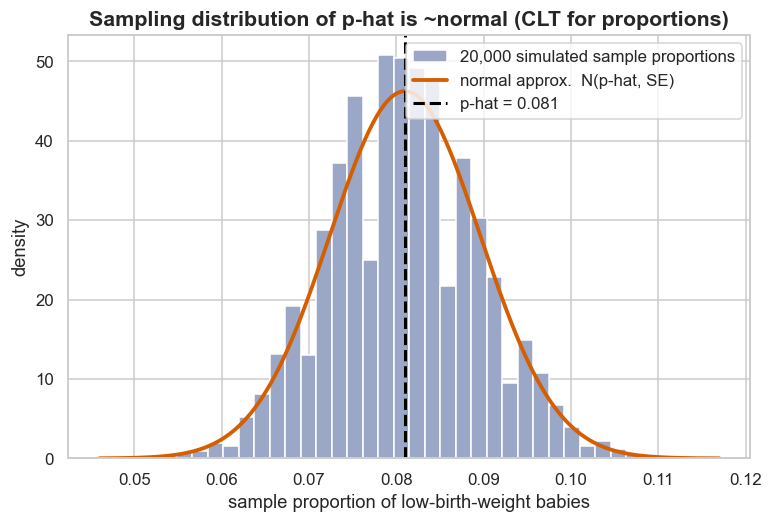

In [5]:
fig, ax = plt.subplots()
ax.hist(sim_phats, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label='20,000 simulated sample proportions')
# Overlay the normal-approximation curve the formula predicts:
xs = np.linspace(sim_phats.min(), sim_phats.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, phat, se_formula), color='#D55E00', lw=2.5,
        label='normal approx.  N(p-hat, SE)')
ax.axvline(phat, color='black', ls='--', lw=2, label=f'p-hat = {phat:.3f}')
ax.set_xlabel('sample proportion of low-birth-weight babies')
ax.set_ylabel('density')
ax.set_title('Sampling distribution of p-hat is ~normal (CLT for proportions)')
ax.legend(); plt.show()

The simulated histogram is a tidy **bell curve** centered on $\hat{p}$, and the red normal curve built
from the *formula* lands right on top of it. That's the **Central Limit Theorem** working for counts:
even though each baby is a yes/no outcome, the **proportion** of yeses across many babies is
approximately **normal**. This is exactly why the z-based recipes below work.

### When is the normal approximation safe? The success/failure conditions

The bell-curve shortcut needs **enough of both** categories. The standard rule of thumb is

$$n\hat{p} \ge 10 \quad\text{and}\quad n(1-\hat{p}) \ge 10$$

— at least about 10 expected "successes" *and* 10 "failures." With very few of either, the sampling
distribution gets lopsided (it can't go below 0 or above 1), and the normal recipe misbehaves.

In [6]:
print(f'n * p-hat       = {n * phat:.0f}   (low-birth-weight babies)   need >= 10? {n*phat >= 10}')
print(f'n * (1 - p-hat) = {n * (1 - phat):.0f}   (normal-weight babies)      need >= 10? {n*(1-phat) >= 10}')
print('\nBoth comfortably clear 10, so the normal-based CI and z-test below are trustworthy.')

n * p-hat       = 81   (low-birth-weight babies)   need >= 10? True
n * (1 - p-hat) = 919   (normal-weight babies)      need >= 10? True

Both comfortably clear 10, so the normal-based CI and z-test below are trustworthy.


## 2) A 95% confidence interval for one proportion

Because $\hat{p}$ is approximately normal, a confidence interval is the familiar **estimate ± margin**:

$$\hat{p} \;\pm\; z^{*}\,\sqrt{\dfrac{\hat{p}(1-\hat{p})}{n}}$$

where $z^{*}$ is the normal multiplier — about **1.96** for 95% (compare the *t*-based intervals for
means; for proportions we use the normal $z$ because there's no separate spread to estimate). Read it as
a **range of plausible values** for the true low-birth-weight rate $p$.

In [7]:
zstar = stats.norm.ppf(0.975)        # 1.96 for 95%
margin = zstar * se_formula
lo, hi = phat - margin, phat + margin
print(f'z* for 95%        = {zstar:.4f}')
print(f'margin of error   = {margin:.4f}  (about +/- {margin*100:.1f} percentage points)')
print(f'95% CI for p      = ({lo:.4f}, {hi:.4f})   ->  ({lo*100:.1f}%, {hi*100:.1f}%)')

# Confirm with statsmodels (it computes the exact same normal interval):
lo_sm, hi_sm = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')
print(f'\nstatsmodels normal CI = ({lo_sm:.4f}, {hi_sm:.4f})   <- matches our hand calculation')

z* for 95%        = 1.9600
margin of error   = 0.0169  (about +/- 1.7 percentage points)
95% CI for p      = (0.0641, 0.0979)   ->  (6.4%, 9.8%)

statsmodels normal CI = (0.0641, 0.0979)   <- matches our hand calculation


**Interpretation (carefully!):** we're 95% confident the true US low-birth-weight rate lies roughly
between **6.4% and 9.8%**. As in the **confidence-interval flagship**, the "95%" is a property of the
*method* — about 95% of intervals built this way capture the truth — **not** a probability that *this*
interval does.

> **A note for the curious.** When successes are scarce, the plain "$\hat p \pm z^*\,\text{SE}$"
> (called the *Wald* interval) can be a bit too optimistic. A sturdier variant, the **Wilson** interval,
> behaves better near 0 or 1. `proportion_confint(..., method='wilson')` gives it. Here, with 81
> successes, the two barely differ — but it's good to know the safer tool exists.

## 3) A one-proportion z-test: does the rate match a benchmark?

Suppose a public-health report claims the national low-birth-weight rate is **8%**. Is our sample
consistent with that, or does it point somewhere else? This is a **hypothesis test**:

- **Null hypothesis** $H_0:\; p = p_0$ — "the true rate really is the benchmark $p_0 = 0.08$."
- **Alternative** $H_A:\; p \neq p_0$ — "it's different" (a two-sided test).

The key twist: we **assume $H_0$ is true** while testing it, so we build the SE from $p_0$, **not** from
$\hat{p}$:

$$z = \dfrac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}.$$

The **p-value** is the chance of seeing a $\hat{p}$ at least this far from $p_0$ *if the null were true*.

### First, see the p-value as an area — by simulating the null world

Let's build the **null distribution** directly: simulate thousands of studies in a world where the true
rate really is exactly $p_0 = 0.08$, and see how often a sample lands as far from 0.08 as ours did. The
p-value is just the **share of that null world** at least as extreme as what we observed.

In [8]:
p0 = 0.08                                  # the benchmark we're testing against
obs_dist = abs(phat - p0)                  # how far OUR sample sat from the benchmark

# Simulate the null world: true rate = p0, draw n births, many times.
null_phats = rng.binomial(n=n, p=p0, size=n_sims) / n
p_value_sim = np.mean(np.abs(null_phats - p0) >= obs_dist)   # two-sided: "at least this far, either way"

print(f'Observed p-hat = {phat:.4f}, which is {obs_dist:.4f} away from p0 = {p0}')
print(f'Simulated two-sided p-value = {p_value_sim:.4f}')

Observed p-hat = 0.0810, which is 0.0010 away from p0 = 0.08
Simulated two-sided p-value = 0.9543


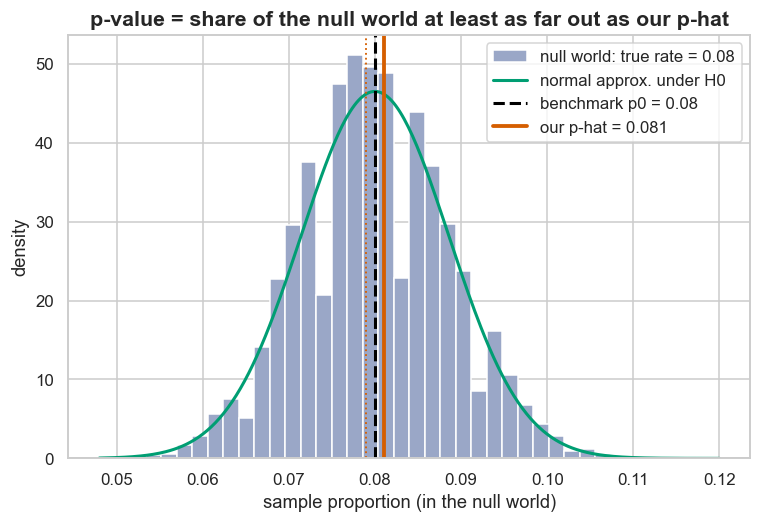

In [9]:
se0 = np.sqrt(p0 * (1 - p0) / n)           # standard error UNDER the null (uses p0, not p-hat)
fig, ax = plt.subplots()
ax.hist(null_phats, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label=f'null world: true rate = {p0}')
xs = np.linspace(null_phats.min(), null_phats.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, p0, se0), color='#009E73', lw=2, label='normal approx. under H0')
ax.axvline(p0, color='black', ls='--', lw=2, label=f'benchmark p0 = {p0}')
ax.axvline(phat, color='#D55E00', lw=2.5, label=f'our p-hat = {phat:.3f}')
ax.axvline(p0 - obs_dist, color='#D55E00', lw=1.2, ls=':')   # the mirror-image cutoff
ax.set_xlabel('sample proportion (in the null world)'); ax.set_ylabel('density')
ax.set_title('p-value = share of the null world at least as far out as our p-hat')
ax.legend(); plt.show()

Our $\hat{p}$ (red) sits **smack in the fat middle** of the null world. A sample like ours is totally
ordinary if the true rate is 8%, so the p-value is large. Now confirm with the textbook z-formula and
with statsmodels.

In [10]:
z_stat = (phat - p0) / se0
p_value_formula = 2 * stats.norm.sf(abs(z_stat))     # sf = 1 - CDF; doubled for two-sided
print(f'z-statistic            = {z_stat:.3f}')
print(f'p-value (z-formula)    = {p_value_formula:.4f}')
print(f'p-value (simulation)   = {p_value_sim:.4f}   <- close, as it should be')

# statsmodels: prop_var=p0 tells it to use the NULL value in the SE (the correct test SE).
z_sm, p_sm = proportions_ztest(count=x, nobs=n, value=p0, prop_var=p0)
print(f'\nstatsmodels: z = {z_sm:.3f}, p = {p_sm:.4f}   <- agrees with the formula')

print(f'\nConclusion: p-value = {p_value_formula:.2f} > 0.05, so we do NOT reject H0.')
print('Our data is fully consistent with a true low-birth-weight rate of 8%.')

z-statistic            = 0.117
p-value (z-formula)    = 0.9072
p-value (simulation)   = 0.9543   <- close, as it should be

statsmodels: z = 0.117, p = 0.9072   <- agrees with the formula

Conclusion: p-value = 0.91 > 0.05, so we do NOT reject H0.
Our data is fully consistent with a true low-birth-weight rate of 8%.


**Not rejecting is not the same as proving.** A large p-value means *"no evidence against 8%"* — not
*"the rate is exactly 8%."* Indeed our CI (6.4%–9.8%) covers a whole range of plausible values, 8% among
them. To feel the contrast, test against a **different** benchmark, say 10%.

In [11]:
for p0_try in [0.08, 0.10]:
    se0_try = np.sqrt(p0_try * (1 - p0_try) / n)
    z_try = (phat - p0_try) / se0_try
    p_try = 2 * stats.norm.sf(abs(z_try))
    verdict = 'reject H0' if p_try < 0.05 else 'do NOT reject H0'
    print(f'H0: p = {p0_try:.2f}  ->  z = {z_try:+.2f},  p-value = {p_try:.4f}  ->  {verdict}')

print('\nA benchmark of 10% sits just OUTSIDE our 95% CI, so the test rejects it (p < 0.05).')
print('Notice how the CI and the test tell the same story: values inside the CI survive the test.')

H0: p = 0.08  ->  z = +0.12,  p-value = 0.9072  ->  do NOT reject H0
H0: p = 0.10  ->  z = -2.00,  p-value = 0.0452  ->  reject H0

A benchmark of 10% sits just OUTSIDE our 95% CI, so the test rejects it (p < 0.05).
Notice how the CI and the test tell the same story: values inside the CI survive the test.


## 4) Two proportions: do smokers and nonsmokers differ?

Now the question with real stakes: is the low-birth-weight **rate different for mothers who smoke?** This
compares **two** proportions. Start, as always, by *counting* — build the 2×2 table.

In [12]:
# Drop the few rows where smoking status is unknown, then cross-tabulate.
b = births.dropna(subset=['habit']).copy()
table = pd.crosstab(b['habit'], b['lowbirthweight'])
table = table[['low', 'not low']]            # order columns for readability
print(table)
print(f'\n(dropped {len(births) - len(b)} births with unknown smoking status)')

lowbirthweight  low  not low
habit                       
nonsmoker        54      813
smoker           24       90

(dropped 19 births with unknown smoking status)


In [13]:
# Group 1 = smokers, group 2 = nonsmokers.
x1 = int(table.loc['smoker', 'low']);     n1 = int(table.loc['smoker'].sum())
x2 = int(table.loc['nonsmoker', 'low']);  n2 = int(table.loc['nonsmoker'].sum())
p1, p2 = x1 / n1, x2 / n2
diff = p1 - p2

print(f'smokers    : {x1:>3} low of {n1:>3}   ->  p1-hat = {p1:.4f}  ({p1*100:.1f}%)')
print(f'nonsmokers : {x2:>3} low of {n2:>3}   ->  p2-hat = {p2:.4f}  ({p2*100:.1f}%)')
print(f'\nobserved difference  p1 - p2 = {diff:.4f}   ({diff*100:.1f} percentage points)')

smokers    :  24 low of 114   ->  p1-hat = 0.2105  (21.1%)
nonsmokers :  54 low of 867   ->  p2-hat = 0.0623  (6.2%)

observed difference  p1 - p2 = 0.1482   (14.8 percentage points)


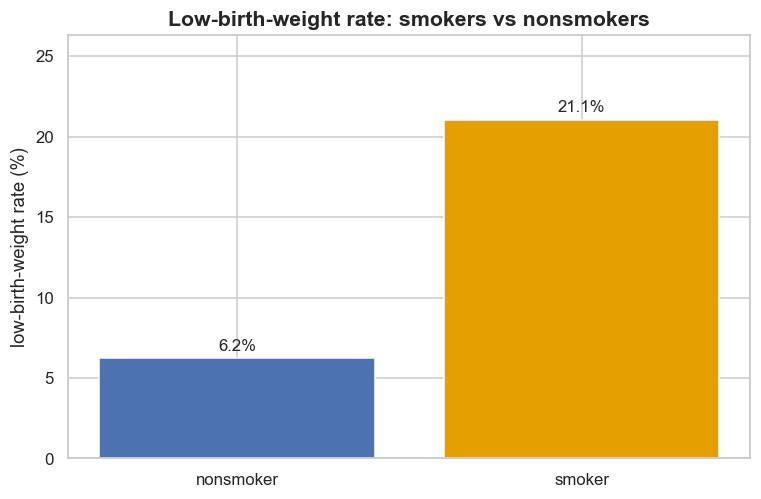

In [14]:
fig, ax = plt.subplots()
groups = ['nonsmoker', 'smoker']
rates = [p2 * 100, p1 * 100]
bars = ax.bar(groups, rates, color=['#4c72b0', '#E69F00'], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('low-birth-weight rate (%)')
ax.set_title('Low-birth-weight rate: smokers vs nonsmokers')
ax.set_ylim(0, max(rates) * 1.25)
plt.show()

Smokers' babies are low-birth-weight about **21%** of the time versus about **6%** for nonsmokers — a gap
of roughly **15 percentage points**. But could a gap this big be **luck** of who happened to land in our
1,000 births? Two tools answer that.

### A confidence interval for the difference $p_1 - p_2$

For a CI we estimate each group's wobble from its **own** $\hat{p}$ and add the variances (independent
groups):

$$(\hat{p}_1 - \hat{p}_2) \;\pm\; z^{*}\sqrt{\dfrac{\hat{p}_1(1-\hat{p}_1)}{n_1} + \dfrac{\hat{p}_2(1-\hat{p}_2)}{n_2}}.$$

In [15]:
se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
margin_d = zstar * se_diff
lo_d, hi_d = diff - margin_d, diff + margin_d
print(f'SE of the difference = {se_diff:.4f}')
print(f'95% CI for p1 - p2   = ({lo_d:.4f}, {hi_d:.4f})')
print(f'                     = ({lo_d*100:.1f},  {hi_d*100:.1f}) percentage points')
print('\nThe entire interval is ABOVE 0, so 0 (no difference) is not plausible:')
print('smokers have a genuinely higher low-birth-weight rate.')

SE of the difference = 0.0391
95% CI for p1 - p2   = (0.0717, 0.2248)
                     = (7.2,  22.5) percentage points

The entire interval is ABOVE 0, so 0 (no difference) is not plausible:
smokers have a genuinely higher low-birth-weight rate.


### A two-proportion z-test

For the **test**, $H_0$ says the two rates are **equal** ($p_1 = p_2$, i.e. their difference is 0). If
they're truly equal, the best estimate of that common rate **pools** both groups together:

$$\hat{p}_{\text{pool}} = \dfrac{x_1 + x_2}{n_1 + n_2}, \qquad
z = \dfrac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}_{\text{pool}}(1-\hat{p}_{\text{pool}})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}.$$

We *pool* here (but not for the CI) because the **null assumes one shared rate** — so we use all the data
to estimate it. Let's first **simulate** the null world: shuffle the smoker/nonsmoker labels at random so
smoking is unrelated to birth weight, and see how often chance alone produces a gap as big as ours.

In [16]:
# PERMUTATION TEST: under H0 the "smoker" label is irrelevant, so reshuffling it
# should give the same low-birth-weight pattern. Build the null distribution of the gap.
labels = b['habit'].to_numpy()
is_low = (b['lowbirthweight'] == 'low').to_numpy()
n_perm = 20000
null_diffs = np.empty(n_perm)
for i in range(n_perm):
    shuffled = rng.permutation(labels)                      # break any smoking<->weight link
    r_smoke = is_low[shuffled == 'smoker'].mean()
    r_non   = is_low[shuffled == 'nonsmoker'].mean()
    null_diffs[i] = r_smoke - r_non

p_perm = np.mean(np.abs(null_diffs) >= abs(diff))           # two-sided
print(f'observed gap = {diff:.4f}')
print(f'biggest gap chance produced in {n_perm:,} shuffles = {np.abs(null_diffs).max():.4f}')
print(f'permutation p-value = {p_perm:.5f}   (= 0; it never happened in these {n_perm:,} shuffles,')
print('                                          the true chance is vanishingly small, not literally zero)')

observed gap = 0.1482
biggest gap chance produced in 20,000 shuffles = 0.1085
permutation p-value = 0.00000   (= 0; it never happened in these 20,000 shuffles,
                                          the true chance is vanishingly small, not literally zero)


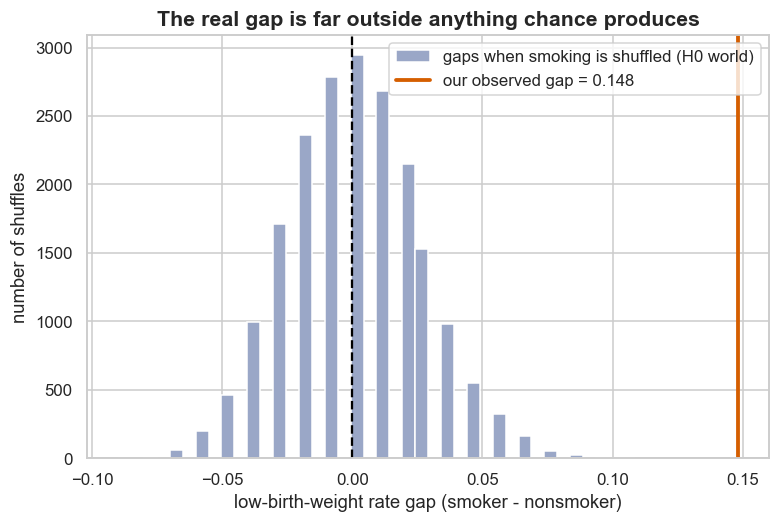

In [17]:
fig, ax = plt.subplots()
ax.hist(null_diffs, bins=40, color='#9aa7c7', edgecolor='white',
        label='gaps when smoking is shuffled (H0 world)')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(diff, color='#D55E00', lw=2.5, label=f'our observed gap = {diff:.3f}')
ax.set_xlabel('low-birth-weight rate gap (smoker - nonsmoker)')
ax.set_ylabel('number of shuffles')
ax.set_title('The real gap is far outside anything chance produces')
ax.legend(); plt.show()

Our real gap (red) is **way out in the wilderness**, far beyond every gap that random shuffling could
manufacture. So the p-value is essentially **zero** — chance is not a credible explanation. Now confirm
with the z-formula and statsmodels.

In [18]:
p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z_two = diff / se_pool
p_two = 2 * stats.norm.sf(abs(z_two))
print(f'pooled p-hat = {p_pool:.4f}')
print(f'z-statistic  = {z_two:.2f}')
print(f'p-value (z-formula)     = {p_two:.2e}')
print(f'p-value (permutation)   = {p_perm:.5f}   <- both say: vanishingly small')

# statsmodels does the pooled two-proportion z-test directly:
z_sm2, p_sm2 = proportions_ztest(count=[x1, x2], nobs=[n1, n2])
print(f'\nstatsmodels: z = {z_sm2:.2f}, p = {p_sm2:.2e}   <- agrees')

pooled p-hat = 0.0795
z-statistic  = 5.50
p-value (z-formula)     = 3.79e-08
p-value (permutation)   = 0.00000   <- both say: vanishingly small

statsmodels: z = 5.50, p = 3.79e-08   <- agrees


### What this does and does **not** prove

- ✅ The smoker–nonsmoker difference is **statistically significant** and **practically large** (the CI
  says roughly 7 to 22 percentage points higher). It is **not** a fluke of sampling.
- ❌ This does **not**, by itself, prove smoking *causes* low birth weight. Births data is
  **observational**, not a randomized experiment — mothers chose whether to smoke. Smokers may differ in
  other ways (a **confounder**: age, nutrition, income, other health factors) that also affect birth
  weight. As the **relationships** lesson warned: *association is not causation.*

The honest sentence is: *"In these data, smoking is strongly associated with a higher low-birth-weight
rate."* (In reality, decades of **randomized and controlled** medical research **do** establish smoking
as a cause — but that evidence comes from study design, not from this z-test alone.)

## Now you try

Predict first, then change a number and re-run:

1. **Tighten or loosen the interval.** In section 2, change `0.975` to `0.995` (a 99% CI) and to `0.95`
   (a 90% CI). Does the interval get **wider** or **narrower**? Does that make the benchmark test in
   section 3 reject more easily or less?

2. **Move the benchmark.** In section 3, the loop tests `p0` = 0.08 and 0.10. Add `0.06` and `0.12` to
   the list. Which benchmarks fall **inside** the 95% CI from section 2, and do those survive the test?
   (You should find the test rejects exactly the values **outside** the CI.)

3. **Re-roll the simulations.** Change `np.random.default_rng(16)` to any other number and re-run the
   one-proportion simulation and the permutation test. Do the simulated SE, the simulated p-value, and
   the permutation p-value barely move? (They should — that's the point of using 20,000 repeats.)

4. **A different two-group split.** Swap `habit` for `mature` (its labels are `'mature mom'` /
   `'younger mom'`) in section 4, re-counting the 2×2 table and recomputing `x1, n1, x2, n2`. Is the
   low-birth-weight rate significantly different for mature versus younger mothers? Build the CI and the
   z-test the same way.

## What you learned

- A **proportion** $\hat{p} = x/n$ estimates the unknown true rate $p$; its wobble is the **standard
  error** $\sqrt{\hat{p}(1-\hat{p})/n}$, which you *saw* by simulating the sampling distribution.
- Because $\hat{p}$ is approximately **normal** (CLT for counts) when $n\hat{p}\ge 10$ and
  $n(1-\hat{p})\ge 10$, a 95% CI is $\hat{p} \pm 1.96\,\text{SE}$.
- A **one-proportion z-test** compares $\hat{p}$ to a benchmark $p_0$, building the SE **from $p_0$**
  (the null value); the **p-value** is the share of the null world at least as extreme as your sample.
- A large p-value means **"no evidence against"** the benchmark — not proof it's exactly right; the CI
  and the test always agree about which values are plausible.
- For **two** proportions, the **CI** uses each group's own SE, but the **test pools** the groups because
  $H_0$ assumes one shared rate.
- A **permutation test** (shuffle the group labels) reproduces the z-test's p-value with no formula at
  all — a powerful sanity check.
- **Significant ≠ causal:** smoking is strongly *associated* with low birth weight in these observational
  data, but causation needs study design, not a single test.

---

**← Previous:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 15: t-tests: one-sample, two-sample & paired](15-t-tests.ipynb)

**Same idea, another way:**  [Another dataset →](14-inference-proportions~another-dataset.ipynb)  ·  [The code behind it →](14-inference-proportions~the-code.ipynb)